In [39]:
import os 
import json
import pandas as pd

In [40]:
results_path = '../experiments/ebe_vs/v2'
naml_result_files = os.listdir(os.path.join(results_path, 'naml'))
naml_result_files = [f for f in naml_result_files if f.endswith('.json')]

# Make a dataframe with the results of the json files
all_results = []
for file in naml_result_files:
    with open(os.path.join(results_path, 'naml', file), 'r') as f:
        result = json.load(f)
        all_results.append(result)
naml_results_df = pd.DataFrame(all_results)
naml_results_df.head()

,seed,data_id,time_taken,max_training_metric,test_accuracy_best_non_nn_model
0,14125,1067,28.893986,0.8710,0.862559
1,14125,1169,1316.738770,0.6587,0.655932
2,14125,12,108.910154,0.9825,0.980000
3,14125,1461,46.616198,0.9079,0.911423
4,14125,1464,18.159330,0.7883,0.800000


In [41]:
results_path = '../experiments/ebe_vs/v2'
standard_result_files = os.listdir(os.path.join(results_path, 'standard'))
standard_result_files = [f for f in standard_result_files if f.endswith('.json')]
mlp_result_files = [f for f in standard_result_files if 'MLP' in f]
non_mlp_result_files = [f for f in standard_result_files if 'MLP' not in f]

# Make a dataframe with the results of the json files
standard_results = []
for file in non_mlp_result_files:
    # extract dataset id and seed of file
    dataset_id = file.split('_')[0]
    seed = file.split('_')[1]
    with open(os.path.join(results_path, 'standard', file), 'r') as f:
        result['dataset_id'] = dataset_id
        result['seed'] = seed
        result = json.load(f)
        standard_results.append(result)

standard_results_df = pd.DataFrame(standard_results)
standard_results_df.head()

,best_model,best_accuracy,total_training_time_sec,hist_gradient_boosting_training_time_sec,all_results,dataset_id,seed
0,SVC,0.857820,0.784354,0.125518,{'LogisticRegression': {'test_acc': 0.84834123...,1169,14125
1,HistGradientBoosting,0.656711,5484.628677,1.140083,{'LogisticRegression': {'test_acc': 0.58276555...,12,14125
2,SVC,0.985000,40.363095,4.363857,"{'LogisticRegression': {'test_acc': 0.9825, 't...",1461,14125
3,RandomForest,0.909654,19.023256,0.215027,{'LogisticRegression': {'test_acc': 0.89085480...,1464,14125
4,LogisticRegression,0.786667,0.274534,0.059503,{'LogisticRegression': {'test_acc': 0.78666666...,1468,14125


In [42]:

# Make a dataframe with the results of the json files
mlp_results = []
for file in mlp_result_files:
    with open(os.path.join(results_path, 'standard', file), 'r') as f:
        result = json.load(f)
        mlp_results.append(result)
mlp_results_df = pd.DataFrame(mlp_results)
mlp_results_df.head()

,seed,data_id,time_taken,train_acc,test_acc,train_loss,val_acc
0,14125,1067,2.636002,0.935981,0.843602,0.197722,NaN
1,14125,1169,120.568452,0.651137,0.646190,0.624145,0.650321
2,14125,12,0.864788,1.000000,0.982500,0.000881,NaN
3,14125,1461,54.370400,0.925929,0.897269,0.173857,NaN
4,14125,1464,0.427563,0.807692,0.806667,0.436421,NaN


In [43]:
ebe_result_files = os.listdir(os.path.join(results_path, 'ebe'))
ebe_result_files = [f for f in ebe_result_files if f.endswith('summary.json')]

# Make a dataframe with the results of the json files
ebe_results = []
for file in ebe_result_files:
 
    with open(os.path.join(results_path, 'ebe', file), 'r') as f:
        result = json.load(f)

        ebe_results.append(result)
ebe_results_df = pd.DataFrame(ebe_results)
ebe_results_df.head()

,seed,data_id,time_factor,time_budget,time_taken,naml_baseline_metric,candidates_created,mean_p_above_goal,median_p_above_goal,max_p_above_goal,...,benefit,training_time,max_test_acc,min_test_loss,best_model_id,n_above_baseline_fcst,max_train_acc,min_train_loss,max_val_acc,min_val_loss
0,14125,1067,12.0,1.506217,2.556189,0.862559,32.0,0.526240,7.002126e-01,0.700246,...,0.137441,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,14125,1067,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,60.645608,0.853081,0.39909,2.0,NaN,NaN,NaN,NaN,NaN
2,14125,1169,131.0,149.350820,284.422391,0.655932,32.0,NaN,NaN,NaN,...,0.217254,NaN,NaN,NaN,NaN,27.0,NaN,NaN,NaN,NaN
3,14125,12,3.0,13.091571,13.199008,0.980000,107.0,0.065245,1.436153e-11,0.449455,...,0.015000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,14125,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,76.837147,0.982500,0.19657,64.0,NaN,NaN,NaN,NaN,NaN


# Plot the results

In [44]:
import matplotlib.pyplot as plt
import seaborn as sns


Text(0, 0.5, 'Time Factor')

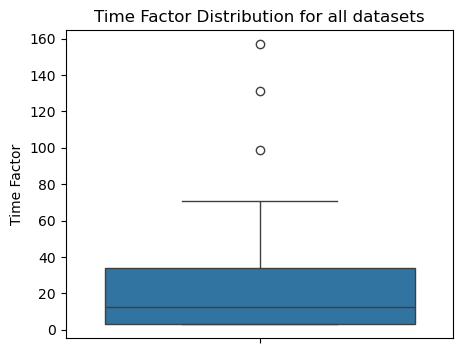

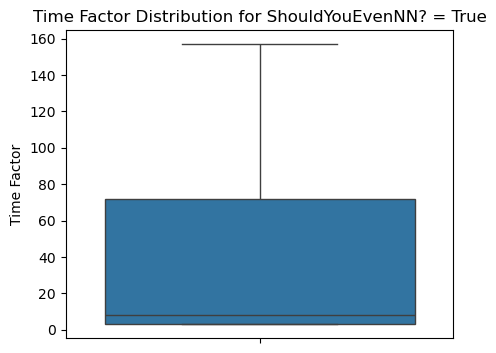

In [45]:
should_you_even_nn_df = ebe_results_df[ebe_results_df['ShouldYouEvenNN?'] == True]
plt.figure(figsize=(5, 4))
# Plot the time factor distributions
sns.boxplot(y='time_factor', data=ebe_results_df)
# Add title and labels
plt.title('Time Factor Distribution for all datasets')
plt.ylabel('Time Factor')

plt.figure(figsize=(5, 4))
# Plot the time factor distributions
sns.boxplot(y='time_factor', data=should_you_even_nn_df)
# Add title and labels
plt.title('Time Factor Distribution for ShouldYouEvenNN? = True')
plt.ylabel('Time Factor')


In [46]:
should_you_even_nn_df['data_id'].unique()

array([ 1169,  1464, 23517,    31, 41142, 41164, 41166])

In [47]:

should_you_even_nn_df = ebe_results_df[ebe_results_df['ShouldYouEvenNN?'] == True]

plt.figure(figsize=(5, 4))
sns.histplot(y='time_factor', data=ebe_results_df, bins=20)
plt.title('Time Factor Distribution for all datasets')
plt.ylabel('Time Factor')
plt.xlabel('Count')
plt.tight_layout()
plt.savefig('time_factor_distribution_all.png')
plt.clf()

plt.figure(figsize=(5, 4))
sns.histplot(y='time_factor', data=should_you_even_nn_df, bins=20)
plt.title('Time Factor Distribution for ShouldYouEvenNN? = True')
plt.ylabel('Time Factor')
plt.xlabel('Count')
plt.tight_layout()
plt.savefig('time_factor_distribution_should_nn.png')
plt.clf()

<Figure size 500x400 with 0 Axes>

<Figure size 500x400 with 0 Axes>

# EBE Top Models

In [48]:
import pandas as pd
data_id = 31
seed = 14125
exp_id = f'{data_id}_{seed}'
# Plot the learning curve of the best models according to EBE
summary_df = pd.read_csv(f'../experiments/ebe_vs/v2/ebe/{data_id}_{seed}_ES_EBE.csv')
summary_df['seed'] = seed
summary_df['data_id'] = data_id

summary_df.head()

,id,train_acc,train_loss,val_acc,val_loss,test_acc,test_loss,lc_train_accs,lc_val_accs,lc_train_losses,lc_val_losses,seed,data_id
0,17,0.448437,1.316050,0.70000,0.649875,0.705,0.643800,"[0.3703125, 0.4484375, 0.58125, 0.6609375, 0.6...","[0.39375, 0.7, 0.7, 0.7, 0.7, 0.7, 0.7, 0.7, 0...","[1.7705409526824951, 1.3160502910614014, 0.954...","[0.7251482009887695, 0.649875283241272, 0.6497...",14125,31
1,0,0.606250,0.748376,0.70000,0.646804,0.700,0.630800,"[0.4078125, 0.4859375, 0.60625, 0.684375, 0.68...","[0.33125, 0.61875, 0.7, 0.7, 0.7, 0.7, 0.7, 0....","[0.9066945314407349, 0.7805912017822265, 0.748...","[0.7316062450408936, 0.6726917028427124, 0.646...",14125,31
2,12,0.745313,0.461021,0.75000,0.566670,0.675,0.558346,"[0.578125, 0.678125, 0.6765625, 0.6703125, 0.6...","[0.69375, 0.7, 0.7, 0.69375, 0.69375, 0.7, 0.7...","[0.7402385115623474, 0.678243899345398, 0.6760...","[0.6458117604255676, 0.6270613312721253, 0.625...",14125,31
3,3,0.473438,0.701891,0.70000,0.675265,0.700,0.675264,"[0.4734375, 0.4796875, 0.515625, 0.66875, 0.69...","[0.7, 0.7, 0.7, 0.7, 0.7, 0.7, 0.7, 0.7, 0.7, ...","[0.7018909573554992, 0.6778229951858521, 0.667...","[0.6752646088600158, 0.6676530241966248, 0.661...",14125,31
4,2,0.746875,0.463554,0.73125,0.576367,0.705,0.505820,"[0.48125, 0.6328125, 0.6515625, 0.64375, 0.667...","[0.6875, 0.69375, 0.6875, 0.69375, 0.7, 0.7062...","[0.8621276408433914, 0.7187441289424896, 0.645...","[0.6298346281051636, 0.6134011030197144, 0.606...",14125,31


In [49]:
standard_results_df

,best_model,best_accuracy,total_training_time_sec,hist_gradient_boosting_training_time_sec,all_results,dataset_id,seed
0,SVC,0.857820,0.784354,0.125518,{'LogisticRegression': {'test_acc': 0.84834123...,1169,14125
1,HistGradientBoosting,0.656711,5484.628677,1.140083,{'LogisticRegression': {'test_acc': 0.58276555...,12,14125
2,SVC,0.985000,40.363095,4.363857,"{'LogisticRegression': {'test_acc': 0.9825, 't...",1461,14125
3,RandomForest,0.909654,19.023256,0.215027,{'LogisticRegression': {'test_acc': 0.89085480...,1464,14125
4,LogisticRegression,0.786667,0.274534,0.059503,{'LogisticRegression': {'test_acc': 0.78666666...,1468,14125
5,LogisticRegression,0.944444,13.650248,8.501946,{'LogisticRegression': {'test_acc': 0.94444444...,1486,14125
6,RandomForest,0.971275,21.981261,0.476869,{'LogisticRegression': {'test_acc': 0.95198026...,1489,14125
7,RandomForest,0.906568,1.516945,0.100506,{'LogisticRegression': {'test_acc': 0.75115633...,1590,14125
8,HistGradientBoosting,0.868257,25.405353,0.217045,{'LogisticRegression': {'test_acc': 0.82342102...,1596,14125
9,RandomForest,0.955913,9203.501465,6.088295,{'LogisticRegression': {'test_acc': 0.72486940...,23517,14125


In [50]:
summary_df.head()

,id,train_acc,train_loss,val_acc,val_loss,test_acc,test_loss,lc_train_accs,lc_val_accs,lc_train_losses,lc_val_losses,seed,data_id
0,17,0.448437,1.316050,0.70000,0.649875,0.705,0.643800,"[0.3703125, 0.4484375, 0.58125, 0.6609375, 0.6...","[0.39375, 0.7, 0.7, 0.7, 0.7, 0.7, 0.7, 0.7, 0...","[1.7705409526824951, 1.3160502910614014, 0.954...","[0.7251482009887695, 0.649875283241272, 0.6497...",14125,31
1,0,0.606250,0.748376,0.70000,0.646804,0.700,0.630800,"[0.4078125, 0.4859375, 0.60625, 0.684375, 0.68...","[0.33125, 0.61875, 0.7, 0.7, 0.7, 0.7, 0.7, 0....","[0.9066945314407349, 0.7805912017822265, 0.748...","[0.7316062450408936, 0.6726917028427124, 0.646...",14125,31
2,12,0.745313,0.461021,0.75000,0.566670,0.675,0.558346,"[0.578125, 0.678125, 0.6765625, 0.6703125, 0.6...","[0.69375, 0.7, 0.7, 0.69375, 0.69375, 0.7, 0.7...","[0.7402385115623474, 0.678243899345398, 0.6760...","[0.6458117604255676, 0.6270613312721253, 0.625...",14125,31
3,3,0.473438,0.701891,0.70000,0.675265,0.700,0.675264,"[0.4734375, 0.4796875, 0.515625, 0.66875, 0.69...","[0.7, 0.7, 0.7, 0.7, 0.7, 0.7, 0.7, 0.7, 0.7, ...","[0.7018909573554992, 0.6778229951858521, 0.667...","[0.6752646088600158, 0.6676530241966248, 0.661...",14125,31
4,2,0.746875,0.463554,0.73125,0.576367,0.705,0.505820,"[0.48125, 0.6328125, 0.6515625, 0.64375, 0.667...","[0.6875, 0.69375, 0.6875, 0.69375, 0.7, 0.7062...","[0.8621276408433914, 0.7187441289424896, 0.645...","[0.6298346281051636, 0.6134011030197144, 0.606...",14125,31


In [51]:
summary_df['data_id'].values

array([31, 31, 31, 31, 31])

In [59]:
standard_results_df['dataset_id'].values

array(['1169', '12', '1461', '1464', '1468', '1486', '1489', '1590',
       '1596', '23517', '31', '3', '40668', '40685', '40975', '40981',
       '40984', '40996', '41027', '41142', '41143', '41146', '41150',
       '41164', '41166', '4135', '54', '54', nan], dtype=object)

In [52]:
# get baseline metric
best_non_nn_metric = naml_results_df[(naml_results_df['data_id'] == data_id) & (naml_results_df['seed'] == seed)]['test_accuracy_best_non_nn_model'].values[0]
print(best_non_nn_metric)

ml_metric = standard_results_df[(standard_results_df['dataset_id'] == str(data_id)) & (standard_results_df['seed'] == str(seed))]['best_accuracy'].values[0]
print(ml_metric)

mlp_metric = mlp_results_df[(mlp_results_df['data_id'] == data_id) & (mlp_results_df['seed'] == seed)]['test_acc'].values[0]
print(mlp_metric)

naml_metric = best_non_nn_metric

ebe_metric = summary_df[(summary_df['data_id'] == data_id) & (summary_df['seed'] == seed)]['test_acc'].values[0]
print(ebe_metric)


0.75
0.5239306478405316
0.74
0.705


In [53]:
# import ast
# import numpy as np
# # region Plotting
# for col in ['lc_train_losses', 'lc_val_losses', 'lc_train_accs', 'lc_val_accs']:
#     def safe_eval(x):
#         x_str = str(x)  # force to string
#         try:
#             return ast.literal_eval(x_str)
#         except (ValueError, SyntaxError):
#             return x_str  # fallback to string if parsing fails
#     summary_df[col] = summary_df[col].apply(safe_eval)

# fig, ax = plt.subplots(figsize=(12, 7))

# # Extract the maximum length of each list
# max_lengths = summary_df['lc_val_accs'].apply(len)

# # If you want to get the maximum length across all lists
# xmax = max_lengths.max()

# # Horizontal reference lines + text
# ax.axhline(y=ml_metric, color='r', linestyle='--', linewidth=1)
# ax.text(xmax - 50, ml_metric, "ml_acc", color='r', va='center', ha='left')

# ax.axhline(y=mlp_metric, color='g', linestyle='--', linewidth=1)
# ax.text(xmax - 40, mlp_metric, "mlp_acc", color='g', va='center', ha='left')

# ax.axhline(y=naml_metric, color='b', linestyle='--', linewidth=1)
# ax.text(xmax - 30, naml_metric, "naml_acc", color='b', va='center', ha='left')

# # ax.axhline(y=oracle_metric, color='black', linestyle='-', linewidth=1)
# # ax.text(xmax, oracle_metric, "oracle_acc", color='black', va='center', ha='left')

# ax.axhline(y=ebe_metric, color='orange', linestyle='--', linewidth=2)
# ax.text(xmax+30, ebe_metric, "ebe_acc", color='black', va='center', ha='left', fontweight='bold')

# # ax.axvline(x=np.max(summary_df['epochs_trained']))
# # Find which series has the overall maximum value
# val_accs_original = np.array(summary_df['lc_val_accs'].tolist(), dtype=object)  # Keep original
# max_values = []
# for i in range(len(summary_df)):
#     series = summary_df['test_acc'].iloc[i]  # Use iloc for safer indexing
#     max_values.append(np.max(series))

# best_series_idx = np.argmax(max_values)

# # Plot individual learning curves
# for i in range(len(summary_df)):
#     series = summary_df['lc_val_accs'].iloc[i]
    
#     if i == best_series_idx:
#         ax.plot(series, alpha=1.0, linewidth=2, label='Best EBE model', color='blue')
#     else:
#         ax.plot(series, alpha=0.2, linewidth=1)

# # NaN padding approach for mean curve (using ORIGINAL data, not truncated)
# max_len = max(len(x) for x in val_accs_original)

# padded_val_accs = []
# for acc_seq in val_accs_original:  # Use original data
#     padded = np.full(max_len, np.nan)
#     padded[:len(acc_seq)] = acc_seq
#     padded_val_accs.append(padded)

# val_accs_padded = np.array(padded_val_accs)

# # Calculate mean and std, ignoring NaN values
# mean_curve = np.nanmean(val_accs_padded, axis=0)
# std_curve = np.nanstd(val_accs_padded, axis=0)

# # Plot mean curve with error bands
# epochs = range(len(mean_curve))
# ax.plot(epochs, mean_curve, color='purple', label='EBE Mean after ES', linewidth=2, alpha=0.7)
# ax.fill_between(epochs, mean_curve-std_curve, mean_curve+std_curve, color='purple', alpha=0.3)

# # Rest of your plotting code...
# ax.set_xlabel("Epoch", fontsize=14)
# ax.set_ylabel("Validation Accuracy", fontsize=14)
# fig.suptitle("Learning Curves by ES vs Benchmarkings", fontsize=14, fontweight='bold')
# ax.set_title(f"for dataset", fontsize=12, color="gray")
# ax.grid(alpha=0.3)
# ax.set_ylim(0.4, 1)
# plt.tight_layout()
# plt.legend()
# plt.savefig(f'../figures/Experiment Results/v2/{exp_id}.png')
# plt.show()

# # endregion

In [54]:
import ast
import numpy as np

In [55]:
def load_and_plot(data_id, seed, dataset_name=''):
    summary_df = pd.read_csv(f'../experiments/ebe_vs/v2/ebe/{data_id}_{seed}_ES_EBE.csv')
    summary_df['seed'] = seed
    summary_df['data_id'] = data_id

    # get baseline metric
    best_non_nn_metric = naml_results_df[(naml_results_df['data_id'] == data_id) & (naml_results_df['seed'] == seed)]['test_accuracy_best_non_nn_model'].values[0]
    # print(best_non_nn_metric)

    ml_metric = standard_results_df[(standard_results_df['dataset_id'] == str(data_id)) & (standard_results_df['seed'] == str(seed))]['best_accuracy'].values[0]
    # print(ml_metric)

    mlp_metric = mlp_results_df[(mlp_results_df['data_id'] == data_id) & (mlp_results_df['seed'] == seed)]['test_acc'].values[0]
    # print(mlp_metric)

    naml_metric = best_non_nn_metric

    ebe_metric = summary_df[(summary_df['data_id'] == data_id) & (summary_df['seed'] == seed)]['test_acc'].values[0]
    print(ebe_metric)

    should_nn = ebe_results_df[(ebe_results_df['data_id'] == data_id) & (ebe_results_df['seed'] == seed)]['ShouldYouEvenNN?'].values[0]
    decision = "Yes, you shouldNN" if should_nn else "No, you shouldnotNN"

    # region Plotting
    for col in ['lc_train_losses', 'lc_val_losses', 'lc_train_accs', 'lc_val_accs']:
        def safe_eval(x):
            x_str = str(x)  # force to string
            try:
                return ast.literal_eval(x_str)
            except (ValueError, SyntaxError):
                return x_str  # fallback to string if parsing fails
        summary_df[col] = summary_df[col].apply(safe_eval)

    fig, ax = plt.subplots(figsize=(12, 7))

    # Extract the maximum length of each list
    max_lengths = summary_df['lc_val_accs'].apply(len)

    # If you want to get the maximum length across all lists
    xmax = max_lengths.max()

    # Horizontal reference lines + text
    ax.axhline(y=ml_metric, color='r', linestyle='--', linewidth=1)
    ax.text(xmax - 50, ml_metric, "ml_acc", color='r', va='center', ha='left')

    ax.axhline(y=mlp_metric, color='g', linestyle='--', linewidth=1)
    ax.text(xmax - 40, mlp_metric, "mlp_acc", color='g', va='center', ha='left')

    ax.axhline(y=naml_metric, color='b', linestyle='--', linewidth=1)
    ax.text(xmax - 30, naml_metric, "naml_acc", color='b', va='center', ha='left')

    # ax.axhline(y=oracle_metric, color='black', linestyle='-', linewidth=1)
    # ax.text(xmax, oracle_metric, "oracle_acc", color='black', va='center', ha='left')

    ax.axhline(y=ebe_metric, color='orange', linestyle='--', linewidth=2)
    ax.text(xmax+30, ebe_metric, "ebe_acc", color='black', va='center', ha='left', fontweight='bold')

    # ax.axvline(x=np.max(summary_df['epochs_trained']))
    # Find which series has the overall maximum value
    val_accs_original = np.array(summary_df['lc_val_accs'].tolist(), dtype=object)  # Keep original
    max_values = []
    for i in range(len(summary_df)):
        series = summary_df['test_acc'].iloc[i]  # Use iloc for safer indexing
        max_values.append(np.max(series))

    best_series_idx = np.argmax(max_values)

    # Plot individual learning curves
    for i in range(len(summary_df)):
        series = summary_df['lc_val_accs'].iloc[i]
        
        if i == best_series_idx:
            ax.plot(series, alpha=1.0, linewidth=2, label='Best EBE model', color='blue')
        else:
            ax.plot(series, alpha=0.2, linewidth=1)

    # NaN padding approach for mean curve (using ORIGINAL data, not truncated)
    max_len = max(len(x) for x in val_accs_original)

    padded_val_accs = []
    for acc_seq in val_accs_original:  # Use original data
        padded = np.full(max_len, np.nan)
        padded[:len(acc_seq)] = acc_seq
        padded_val_accs.append(padded)

    val_accs_padded = np.array(padded_val_accs)

    # Calculate mean and std, ignoring NaN values
    mean_curve = np.nanmean(val_accs_padded, axis=0)
    std_curve = np.nanstd(val_accs_padded, axis=0)

    # Plot mean curve with error bands
    epochs = range(len(mean_curve))
    ax.plot(epochs, mean_curve, color='purple', label='EBE Mean after ES', linewidth=2, alpha=0.7)
    ax.fill_between(epochs, mean_curve-std_curve, mean_curve+std_curve, color='purple', alpha=0.3)

    # Rest of your plotting code...
    ax.set_xlabel("Epoch", fontsize=14)
    ax.set_ylabel("Validation Accuracy", fontsize=14)
    fig.suptitle("Learning Curves by ES vs Benchmarkings", fontsize=14, fontweight='bold')
    ax.set_title(f"for dataset {dataset_name} \n Decision:{decision}", fontsize=12, color="gray")
    ax.grid(alpha=0.3)
    ax.set_ylim(0.4, 1)
    plt.tight_layout()
    plt.legend()
    plt.savefig(f'../figures/Experiment Results/v2/{exp_id}.png')
    plt.show()

    # endregion

Processing dataset kr-vs-kp with id 3...
0.978125


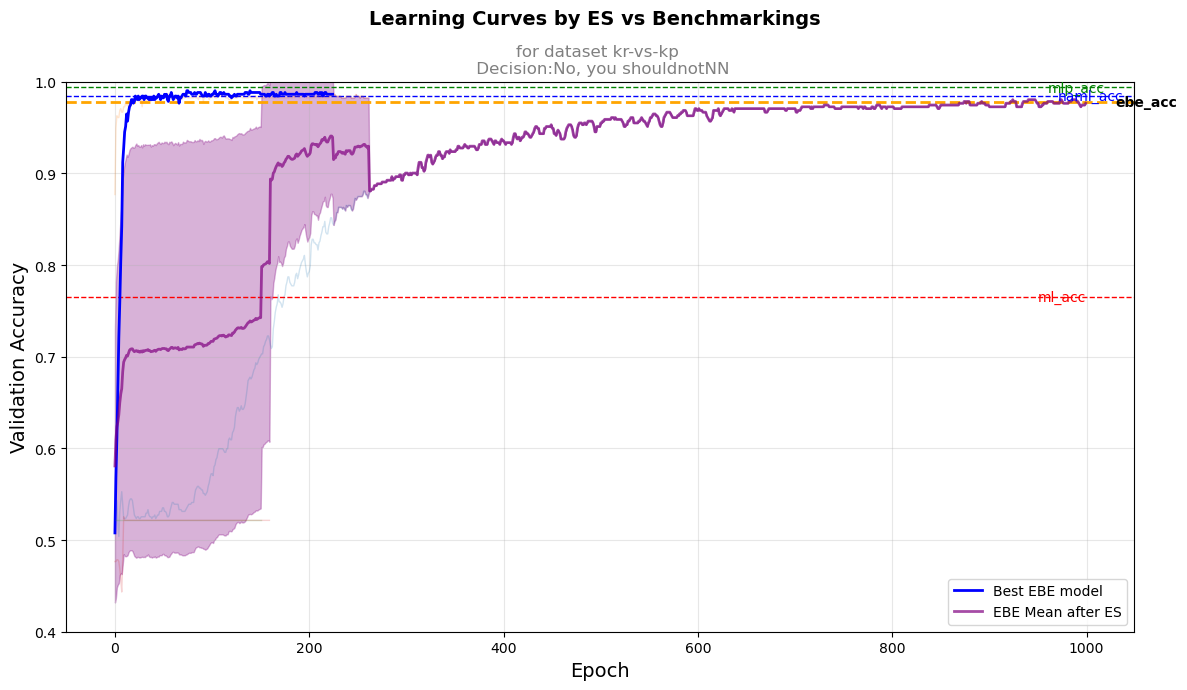

Processing dataset mfeat-factors with id 12...
0.97


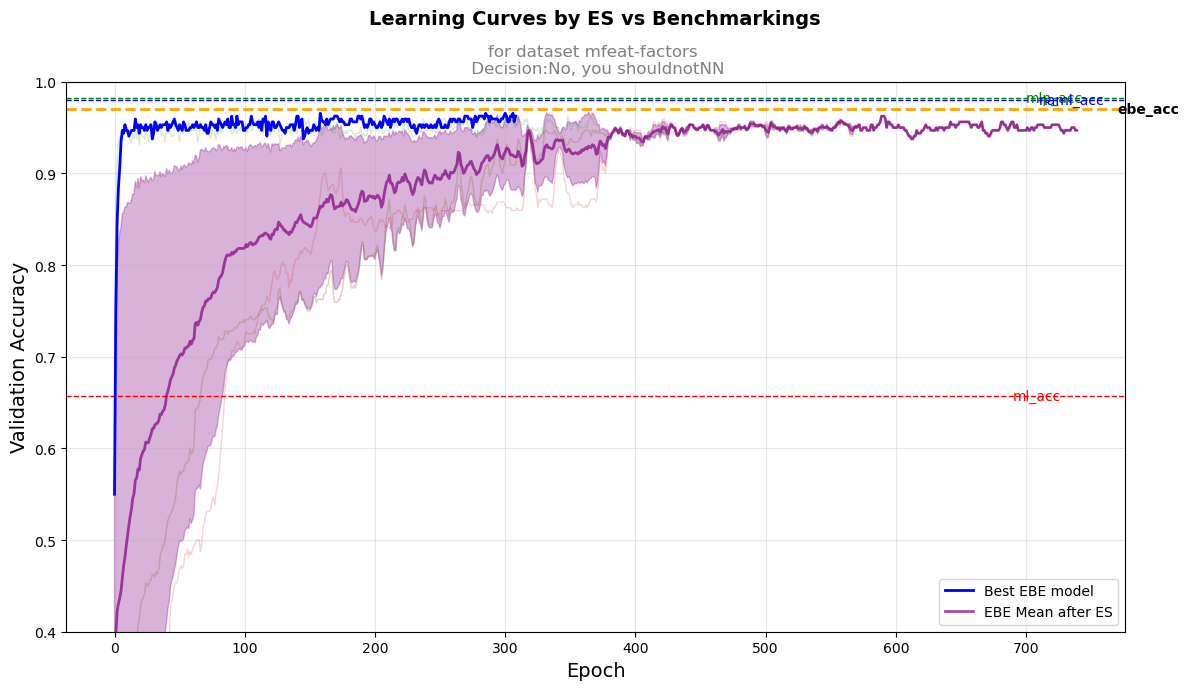

Processing dataset credit-g with id 31...
0.705


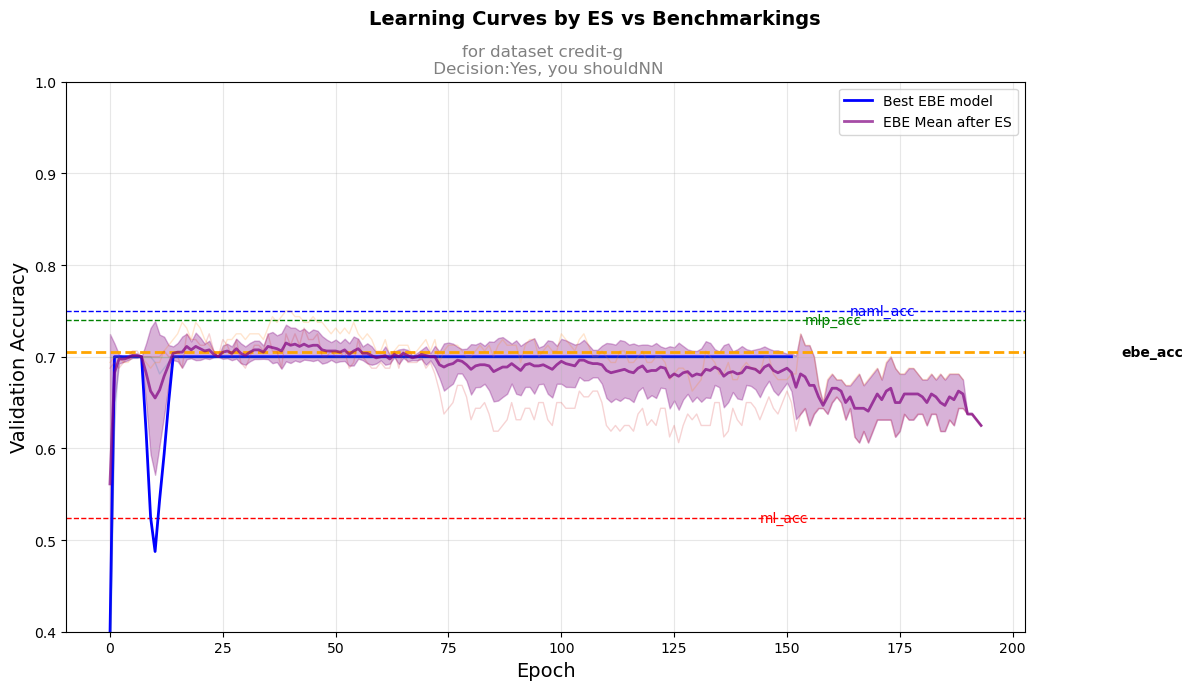

Processing dataset vehicle with id 54...
0.7823529411764706


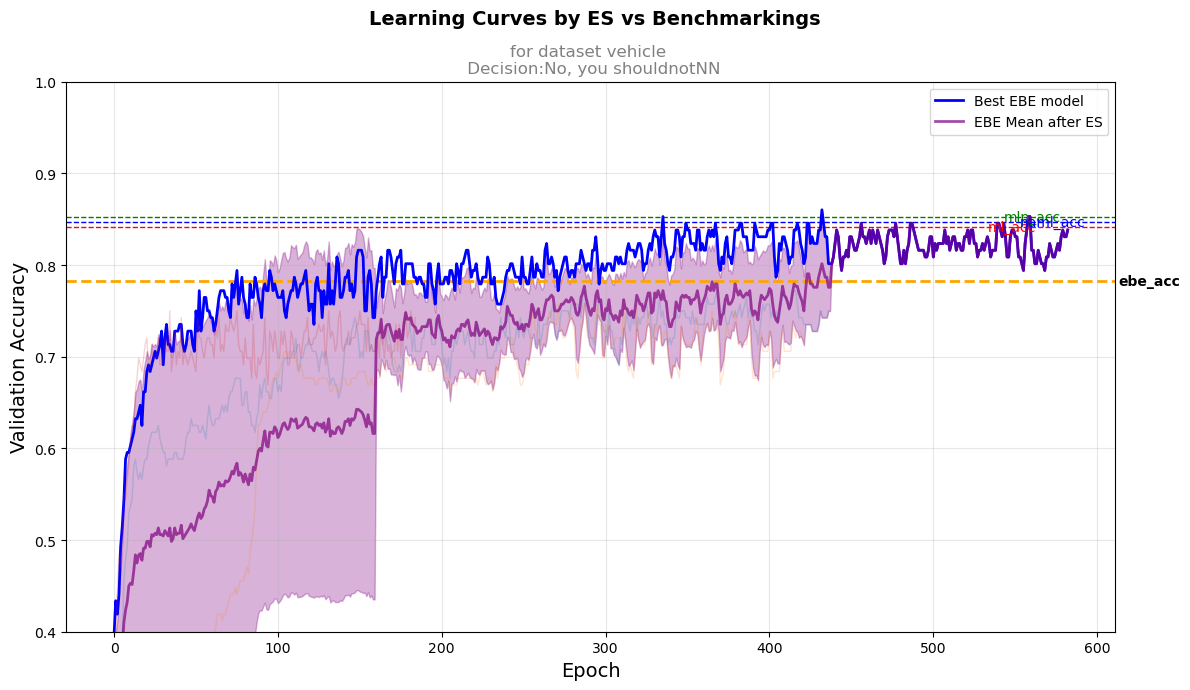

Processing dataset kc1 with id 1067...
Processing dataset KDDCup09_appetency with id 1111...
Processing dataset airlines with id 1169...
Processing dataset bank-marketing with id 1461...
0.905783478933982


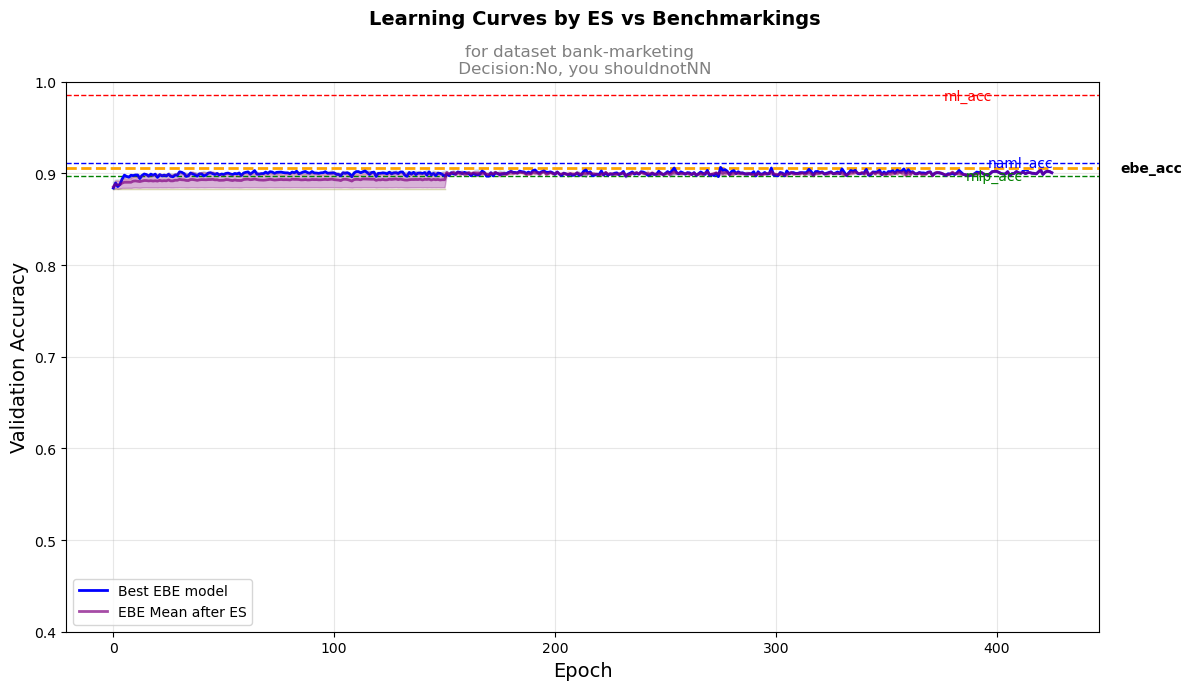

Processing dataset blood-transfusion-service-center with id 1464...
0.7666666666666667


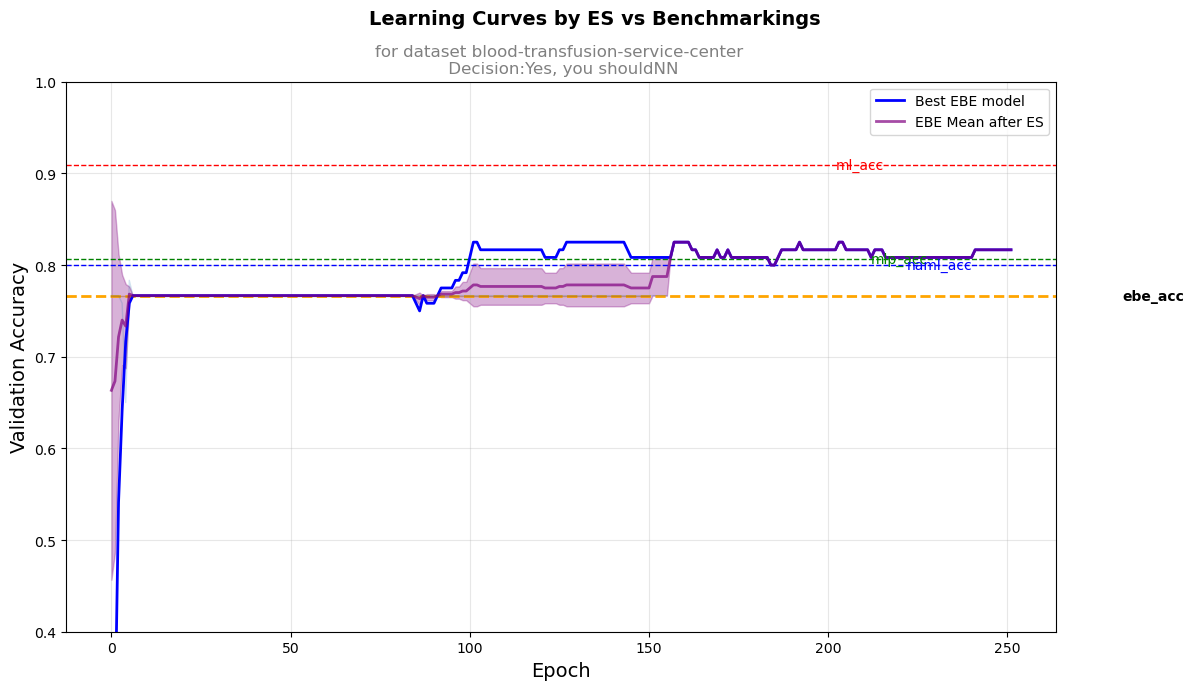

Processing dataset cnae-9 with id 1468...
0.1157407407407407


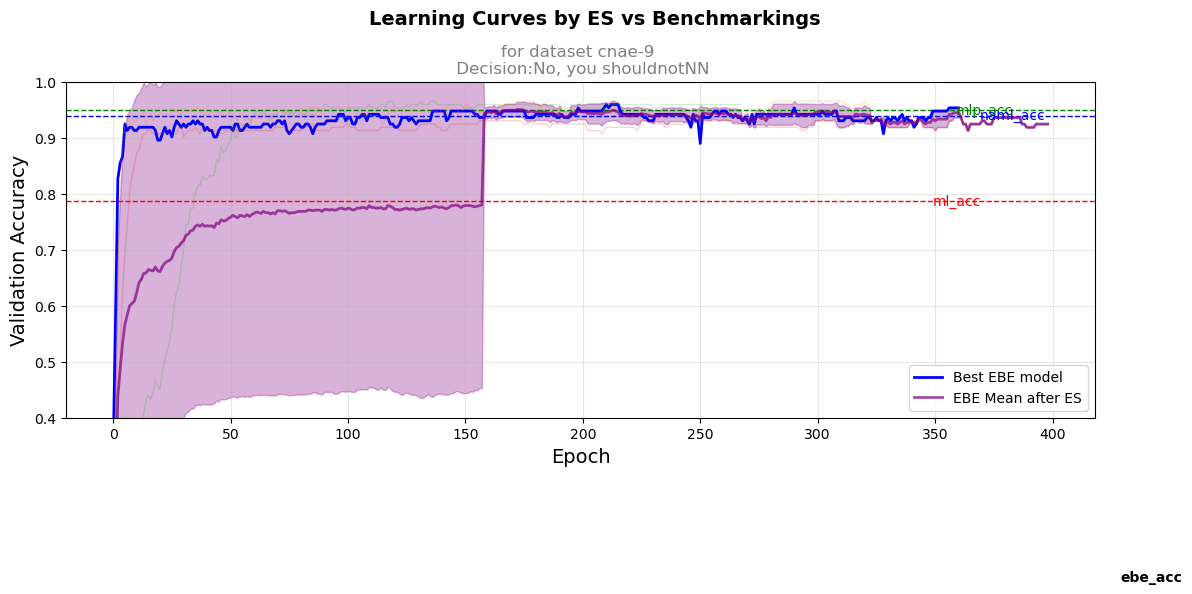

Processing dataset nomao with id 1486...
0.9628608733497752


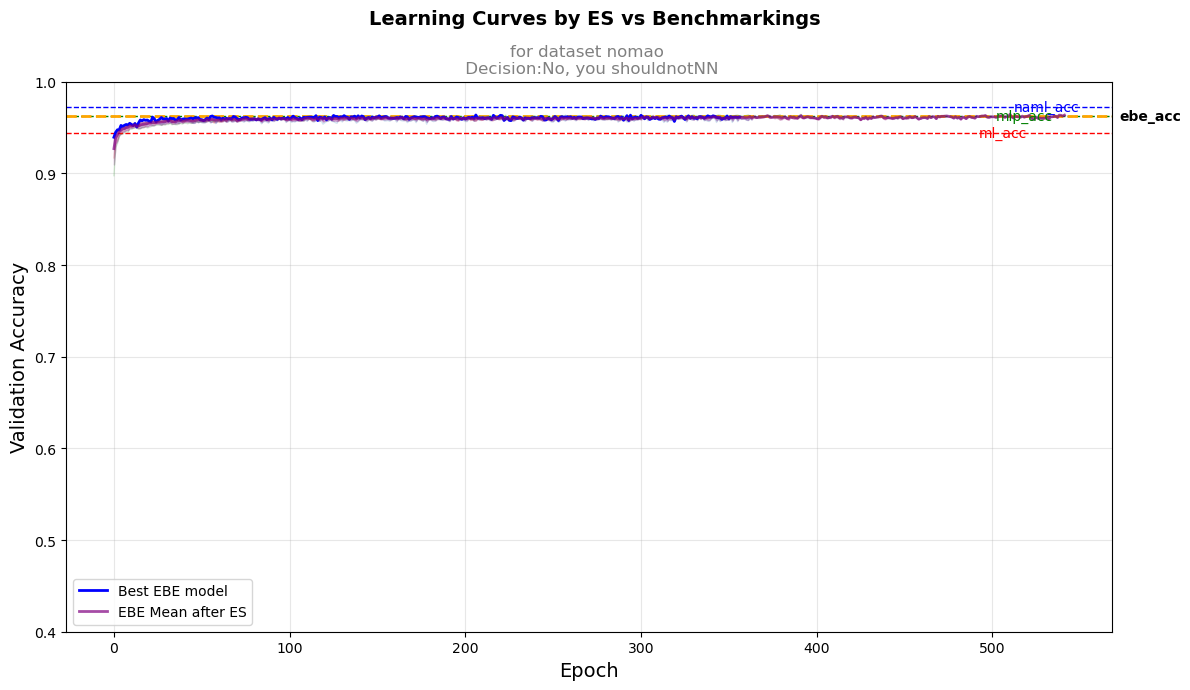

Processing dataset phoneme with id 1489...
0.7095282146160962


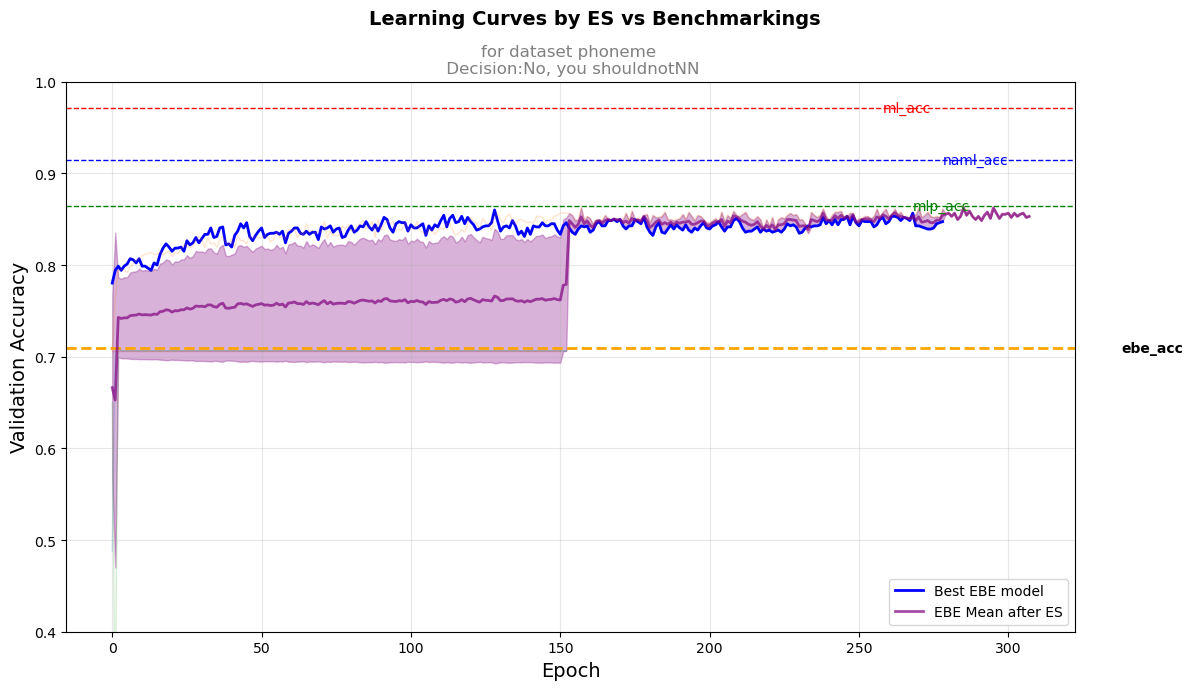

Processing dataset adult with id 1590...
Processing dataset covertype with id 1596...
Processing dataset Amazon_employee_access with id 4135...


In [61]:
dataset_ids_path = '../experiments/datasets/openml_datasets.json'
with open(dataset_ids_path) as f:
    dataset_ids = json.load(f)
    seed = 14125
    for dataset_name, data_id in list(dataset_ids.items())[:15]:
        try:
            print(f'Processing dataset {dataset_name} with id {data_id}...')
            load_and_plot(data_id, seed, dataset_name)
        except Exception as e:
            pass